### Imports

In [1]:
import statistics
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm

from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.utils.preprocessing_utils import get_waveform_transformer, get_spectrogram_transformer, get_cnn_pipeline

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [2]:
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Profiling AudioMNIST dataset

Number of Files: 30000
Sample Rates: {48000: 30000}
Channels: {1: 30000}

[Durations]
Min: 0.29s
Max: 1.0s
Mean: 0.64s
95th Percentile: 0.84s


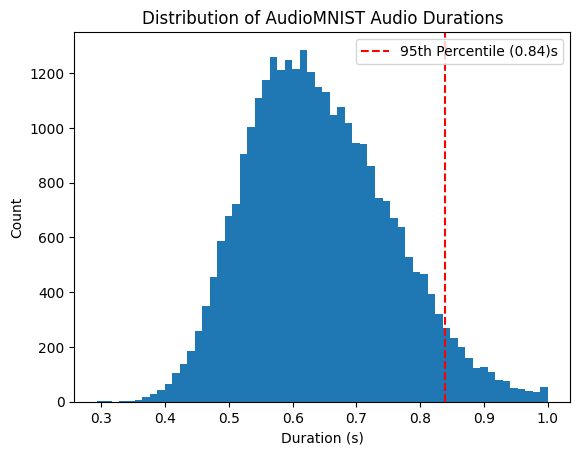

In [3]:
def run_profiling() -> None:
    durations = []
    sample_rates = Counter()
    channels = Counter()

    for file in tqdm(DATASET.input_dir.rglob('*.wav'), desc='Profiling', unit='files', leave=False):
        info = torchaudio.info(file)
        sample_rates[info.sample_rate] += 1
        channels[info.num_channels] += 1
        durations.append(info.num_frames / info.sample_rate)

    print(f'Number of Files: {len(durations)}')
    print(f'Sample Rates: {dict(sample_rates)}')
    print(f'Channels: {dict(channels)}')
    print()
    print('[Durations]')
    print(f'Min: {min(durations):.2f}s')
    print(f'Max: {max(durations):.2}s')
    print(f'Mean: {statistics.mean(durations):.2f}s')
    p95 = np.percentile(durations, 95)
    print(f'95th Percentile: {p95:.2f}s')

    plt.hist(durations, bins=60)
    plt.axvline(p95, color='red', linestyle='dashed', label=f'95th Percentile ({p95:.2f}s)')
    plt.title('Distribution of AudioMNIST Audio Durations')
    plt.xlabel('Duration (s)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

run_profiling()

### Visualising audioMNIST audio as Mel Spectograms

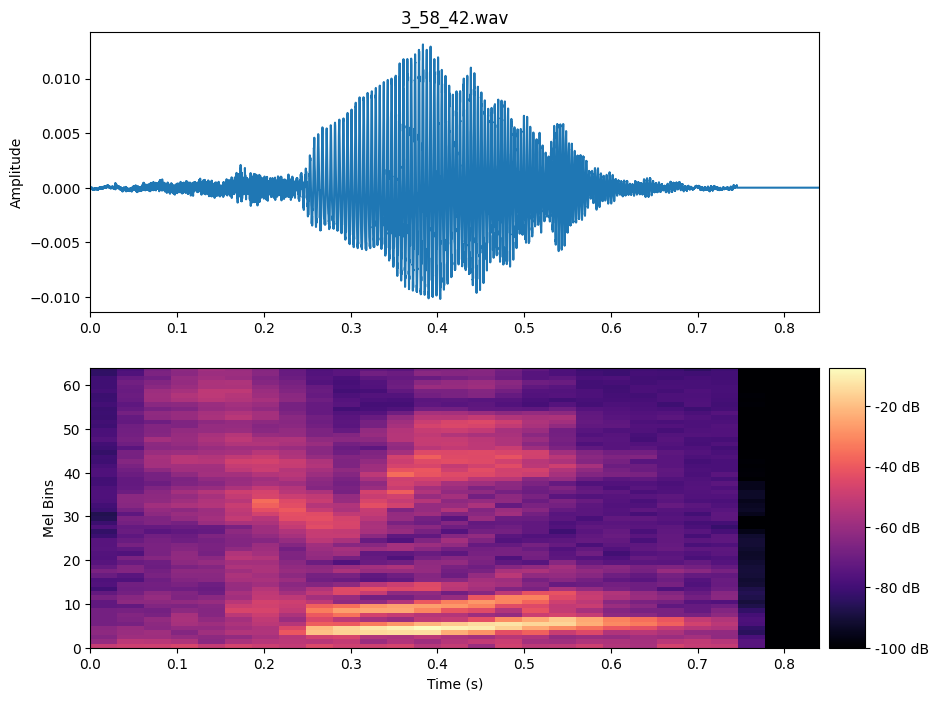

Original: 35778 samples (0.75s)
Preprocessed: 13440 samples (0.84s)


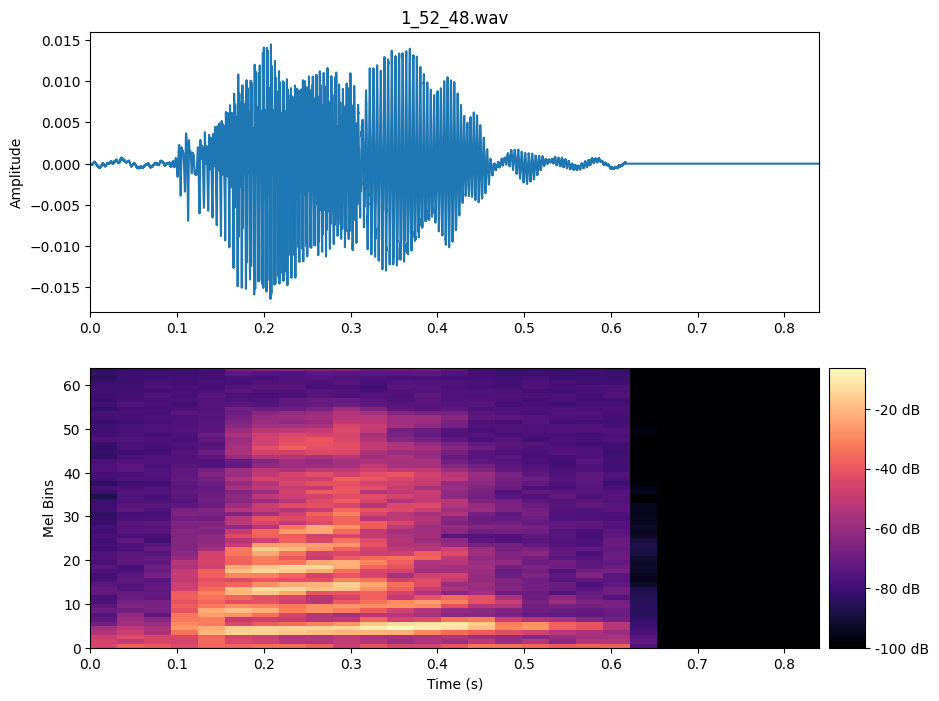

Original: 29629 samples (0.62s)
Preprocessed: 13440 samples (0.84s)


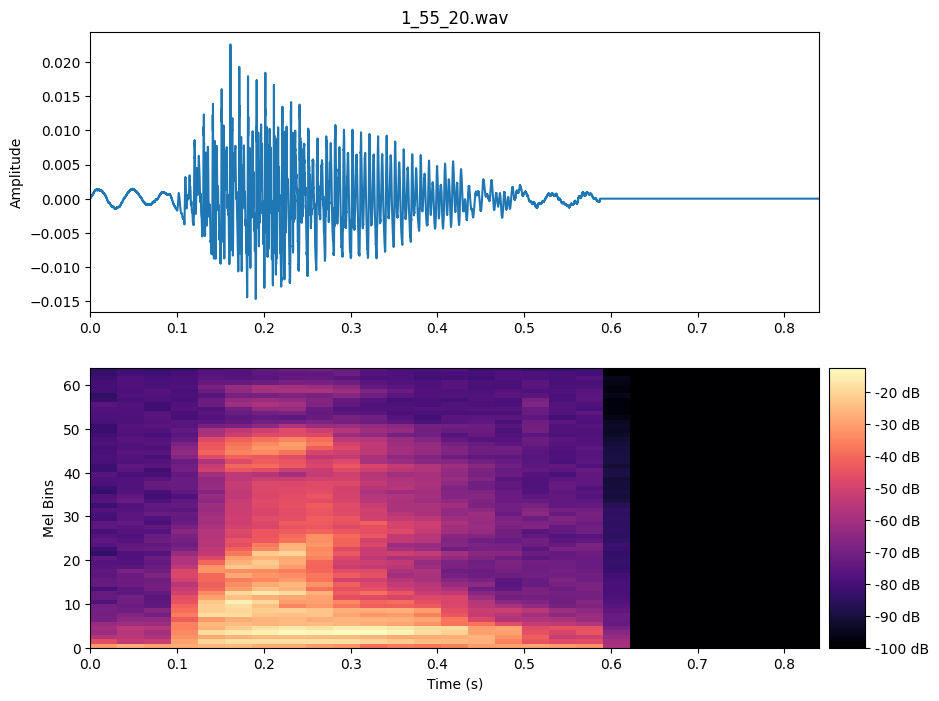

Original: 28186 samples (0.59s)
Preprocessed: 13440 samples (0.84s)


In [4]:
def get_random_audio(dir: Path) -> Path:
    digit = np.random.randint(0, 10)
    speaker = np.random.randint(1, 61)
    sample = np.random.randint(0, 50)

    if speaker < 10:
        return dir / f'0{speaker}/{digit}_0{speaker}_{sample}.wav'
    else:
        return dir / f'{speaker}/{digit}_{speaker}_{sample}.wav'

def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer(DATASET.config)
    spectrogram_transformer = get_spectrogram_transformer(DATASET.config, FILTERBANK)

    for i in range(3):
        file = get_random_audio(DATASET.input_dir)

        raw_waveform, raw_sample_rate = torchaudio.load(file)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / DATASET.config.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file.name)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, DATASET.config.n_bins],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.show()

        display(Audio(data=new_waveform, rate=DATASET.config.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')

visualise_audio_data()

### Confirming input shape

In [5]:
def get_sample_input_shape() -> None:
    pipeline = get_cnn_pipeline(DATASET.config, FILTERBANK)
    sample_wav, _ = torchaudio.load(next(DATASET.input_dir.rglob('*.wav')))
    sample_spectrogram = pipeline(sample_wav)
    print(f'Input Shape: {sample_spectrogram.shape}')

get_sample_input_shape()

Input Shape: torch.Size([1, 64, 27])
